### Project 1 - House Price

You are provided with a dataset containing information about houses and **prices**. The dataset is already split into `train.csv` and `test.csv`. The `data_description.txt` file contains descriptions of the columns.

**Goal:** Build models to predict house prices.

Please include detailed explanations of the following steps:

1. Data cleaning and preprocessing.

2. Model training and validation.

3. Model comparison based on regression metrics.

**Note:** You are **encouraged** to look for other machine learning algorithms online (beyond the course material), but you must study and understand these algorithms. You must not remove any rows from the `test.csv` file.

## Data Cleaning and Preprocessing

**Data Loading and Outlier Removal**

We begin by loading the training and testing datasets. Based on our EDA of the `GrLivArea` vs. `SalePrice` relationship, we identified extreme outliers (houses with massive square footage but unusually low prices). We remove these from the training set to prevent them from skewing our model's predictions.

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# Load initial datasets
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# Remove extreme outliers from training data to improve model accuracy
train = train.drop(train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)].index)

**Feature Engineering and Target Transformation**

Next, we engineer a new feature, `TotalSF`, by combining the square footage of the basement, first floor, and second floor. We also apply a log transformation (`np.log1p`) to the target variable, `SalePrice`. This compresses the right-skewed "long tail" of expensive houses, creating a more normal distribution that is easier for linear algorithms to model.

In [11]:
# Create a combined square footage feature for both datasets
train['TotalSF'] = train['TotalBsmtSF'].fillna(0) + train['1stFlrSF'].fillna(0) + train['2ndFlrSF'].fillna(0)
test['TotalSF'] = test['TotalBsmtSF'].fillna(0) + test['1stFlrSF'].fillna(0) + test['2ndFlrSF'].fillna(0)

# Apply log transformation to normalize the target variable distribution
train['SalePrice_Log'] = np.log1p(train['SalePrice'])

**Missing Value Imputation and Categorical Encoding**

We define a robust cleaning function that applies several strategies to handle missing data. It restores intentional `NA` categories defined in the data dictionary (e.g., `None` for "No Pool"), imputes specific numerical gaps with logical defaults, and uses a catch-all strategy (median for numbers, mode for text) to ensure zero rows are dropped. Finally, it converts all categorical text into binary indicator columns (One-Hot Encoding).

In [12]:
def clean_and_encode(df):
    df_clean = df.copy()
    
    cols_with_na_meaning = [
        'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
        'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 
        'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType'
    ]
    
    # Restore intentional NA categories defined in the data dictionary
    for col in cols_with_na_meaning:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna('None')
            
    # Impute specific numerical gaps with logical defaults
    if 'MasVnrArea' in df_clean.columns:
        df_clean['MasVnrArea'] = df_clean['MasVnrArea'].fillna(0.0)
    if 'LotFrontage' in df_clean.columns:
        df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(df_clean['LotFrontage'].median())
    if 'GarageYrBlt' in df_clean.columns:
        df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(0)
        
    # Catch-all imputation for any remaining missing values to prevent dropping rows
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if pd.api.types.is_numeric_dtype(df_clean[col]):
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            else:
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    # Convert categorical text into binary indicator columns
    df_encoded = pd.get_dummies(df_clean, dtype=int)    
    return df_encoded

# Process both datasets through the cleaning pipeline
train_encoded = clean_and_encode(train)
test_encoded = clean_and_encode(test)

**Data Alignment and Scaling**

Because `pd.get_dummies` might create different columns depending on the unique values present in the train versus test sets, we must align them to ensure identical feature structures. We then isolate our predictors from the target variables and apply a `RobustScaler` to normalize the numerical ranges while minimizing the impact of any remaining minor outliers.

In [13]:
# Align columns to ensure the test set matches the train set feature structure exactly
train_aligned, test_aligned = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# Remove target variables from the test set to prevent data leakage
if 'SalePrice' in test_aligned.columns:
    test_aligned = test_aligned.drop(columns=['SalePrice'])
if 'SalePrice_Log' in test_aligned.columns:
    test_aligned = test_aligned.drop(columns=['SalePrice_Log'])

# Isolate target and predictors before scaling
y_train = train_aligned['SalePrice_Log']
X_train = train_aligned.drop(columns=['SalePrice', 'SalePrice_Log'])
X_test = test_aligned

# Scale numerical features to reduce the impact of remaining outliers
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Final verification prints
print(f"Final X_train shape: {X_train_scaled.shape}")
print(f"Final y_train shape: {y_train.shape}")
print(f"Final X_test shape: {X_test_scaled.shape}")
print(f"\nMissing values in X_train: {X_train_scaled.isnull().sum().sum()}")
print(f"Missing values in X_test: {X_test_scaled.isnull().sum().sum()}")

Final X_train shape: (1312, 300)
Final y_train shape: (1312,)
Final X_test shape: (146, 300)

Missing values in X_train: 0
Missing values in X_test: 0


# Model Training and Validation

### Validation setup

- **Target scale.** Every model predicts `log1p(SalePrice)`, so RMSE and MAE in the CV results are on the log scale. A log-RMSE of 0.12 means a typical error of roughly 12% of the price, whether the house is cheap or expensive.
- **5-Fold Cross-Validation.** The training set is split into 5 folds. Each fold is used once for validation while the model trains on the other 4. This gives every model 5 scores: the **mean** estimates expected performance, the **std** shows how stable the model is across different data subsets.
- **Holdout set.** `test.csv` still contains `SalePrice`. It is never used for training or tuning, only once at the end for the final comparison.
- **`Id` is dropped.** It is a row number, not a property of the house.

In [14]:
from sklearn.model_selection import KFold, cross_validate

# Id only identifies a row; tree models could still learn spurious splits on it
features = X_train_scaled.columns.drop('Id')
X = X_train_scaled[features]
X_holdout = X_test_scaled[features]

# test.csv keeps SalePrice, so it serves as an untouched holdout on the same log scale
y_holdout = np.log1p(test['SalePrice'])

# Shuffle before splitting in case train.csv rows are ordered
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# sklearn always maximizes a score, so error metrics are returned negated
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2',
}

cv_results = {}
fitted_models = {}

def evaluate_cv(name, model):
    """Score a model with K-Fold CV, then refit it on the full training set."""
    scores = cross_validate(model, X, y_train, cv=kf, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'CV RMSE': -scores['test_rmse'].mean(),
        'CV RMSE std': scores['test_rmse'].std(),
        'CV MAE': -scores['test_mae'].mean(),
        'CV R2': scores['test_r2'].mean(),
    }
    fitted_models[name] = model.fit(X, y_train)
    return pd.Series(cv_results[name])

### Baseline: regularized linear models

With 299 features, many of them correlated one-hot columns, plain linear regression overfits easily. Regularization adds a penalty on the size of the coefficients:

- **Ridge (L2 penalty)** shrinks all coefficients toward zero but keeps every feature.
- **Lasso (L1 penalty)** can push coefficients to exactly zero, so it also performs feature selection.
- **ElasticNet** combines both penalties; `l1_ratio` sets the mix (1.0 = pure Lasso, 0.0 = pure Ridge).

The penalty strength `alpha` is chosen with `GridSearchCV` on the same 5 folds. Because `alpha` is selected to minimize the error on these folds, the CV score of the tuned model is slightly optimistic; the holdout set checks this at the end.

These models are the **baseline**: a more complex model is only worth it if it beats them.

In [15]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

# alpha is searched on a log scale because its effect is multiplicative;
# below 10^-3.5 ElasticNet with a small l1_ratio stops converging
linear_searches = {
    'Ridge': GridSearchCV(
        Ridge(),
        {'alpha': np.logspace(-2, 3, 30)},
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1,
    ),
    'Lasso': GridSearchCV(
        Lasso(max_iter=10000),
        {'alpha': np.logspace(-3.5, -2, 15)},
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1,
    ),
    'ElasticNet': GridSearchCV(
        ElasticNet(max_iter=10000),
        {'alpha': np.logspace(-3.5, -2, 10), 'l1_ratio': [0.1, 0.5, 0.9]},
        cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1,
    ),
}

for name, search in linear_searches.items():
    search.fit(X, y_train)
    print(f"{name} best params: {search.best_params_}")
    evaluate_cv(name, search.best_estimator_)

pd.DataFrame(cv_results).T.loc[list(linear_searches)]

Ridge best params: {'alpha': np.float64(12.689610031679234)}
Lasso best params: {'alpha': np.float64(0.0005179474679231213)}
ElasticNet best params: {'alpha': np.float64(0.001), 'l1_ratio': 0.5}


,CV RMSE,CV RMSE std,CV MAE,CV R2
Ridge,0.115394,0.006297,0.080198,0.916685
Lasso,0.113855,0.007005,0.078592,0.918693
ElasticNet,0.113821,0.006687,0.078611,0.918801


### Random Forest

A Random Forest trains many decision trees. Each tree sees a bootstrap sample of the rows and, at every split, only a random subset of the features. A single deep tree overfits, but averaging many decorrelated trees cancels out much of that variance.

Trees split on thresholds, so they capture non-linear effects and interactions between features (e.g. quality matters more for larger houses) without manual feature engineering, and they do not need scaled inputs.

Tuned hyperparameters:

- `n_estimators`: number of trees. More trees give more stable predictions but train slower.
- `max_depth`: maximum depth of each tree. `None` grows trees until leaves are pure.
- `min_samples_leaf`: minimum number of rows in a leaf. Larger values give smoother predictions.
- `max_features`: share of features considered at each split. Smaller values make trees more diverse.

The default model is evaluated first to measure what tuning adds. `RandomizedSearchCV` then tries 20 random combinations out of 108. This is much cheaper than a full grid and usually lands close to the best result, because only a few hyperparameters have a large effect.

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

evaluate_cv('Random Forest (default)', RandomForestRegressor(random_state=42, n_jobs=-1))

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    {
        'n_estimators': [200, 400, 600],
        'max_depth': [None, 10, 20],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [1.0, 0.5, 0.3, 'sqrt'],
    },
    n_iter=20, cv=kf, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1,
)
rf_search.fit(X, y_train)
print(f"Random Forest best params: {rf_search.best_params_}")
evaluate_cv('Random Forest (tuned)', rf_search.best_estimator_)

pd.DataFrame(cv_results).T.loc[['Random Forest (default)', 'Random Forest (tuned)']]

Random Forest best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': None}


,CV RMSE,CV RMSE std,CV MAE,CV R2
Random Forest (default),0.141362,0.006609,0.097843,0.875508
Random Forest (tuned),0.133677,0.008395,0.090512,0.888547


### Gradient Boosting: XGBoost

*This algorithm goes beyond the course material.*

Random Forest builds its trees independently and averages them. Gradient boosting builds trees **sequentially**: each new tree is fitted to the residual errors of the ensemble built so far (more precisely, to the gradient of the loss), and its prediction is added with a small weight, the `learning_rate`. Many shallow trees, each correcting a little of the remaining error, add up to a strong model.

XGBoost is a widely used implementation of this idea. On top of plain gradient boosting it adds L1/L2 regularization on leaf values, uses second-order (Newton) information about the loss to choose splits, and supports row and column subsampling.

Tuned hyperparameters:

- `n_estimators` and `learning_rate` work as a pair: smaller steps need more trees but usually generalize better.
- `max_depth`: boosting relies on shallow trees. Depth 1 (stumps) cannot model feature interactions at all.
- `min_child_weight`: for squared error this is the minimum number of rows in a leaf; larger values regularize.
- `subsample`: share of rows each tree is trained on.
- `colsample_bytree`: share of features each tree may use.

Many configurations end up within a few thousandths of RMSE from each other, which is smaller than the fold-to-fold std. The exact "best" parameters therefore partly reflect noise; what matters is that tuning moves the model well away from the defaults.

In [18]:
from xgboost import XGBRegressor

evaluate_cv('XGBoost (default)', XGBRegressor(random_state=42))

# n_jobs=1 per model: the search already runs one fit per CPU core
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=1),
    {
        'n_estimators': [500, 1000, 2000, 3000],
        'learning_rate': [0.01, 0.03, 0.05, 0.1],
        'max_depth': [1, 2, 3, 4, 6],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.3, 0.5, 0.7, 1.0],
    },
    n_iter=30, cv=kf, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1,
)
xgb_search.fit(X, y_train)
print(f"XGBoost best params: {xgb_search.best_params_}")
evaluate_cv('XGBoost (tuned)', xgb_search.best_estimator_)

pd.DataFrame(cv_results).T.loc[['XGBoost (default)', 'XGBoost (tuned)']]

XGBoost best params: {'subsample': 0.8, 'n_estimators': 3000, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.5}


,CV RMSE,CV RMSE std,CV MAE,CV R2
XGBoost (default),0.139032,0.007580,0.097053,0.879394
XGBoost (tuned),0.116514,0.005577,0.078306,0.915163


# Model Comparison based on Regression Metrics

### Comparison table

- **CV columns**: mean over the 5 folds of the training set. These are the numbers used to compare and select models.
- **Holdout columns**: a single score on `test.csv` (146 houses), computed only after all tuning was finished. Because the holdout never influenced any choice, it is an unbiased check of the CV estimates.
- All RMSE, MAE and R² values are on the log scale, except `Holdout MAE ($)`, which converts predictions back with `expm1` to show the typical error in dollars.
- Rows are sorted by `CV RMSE` (lower is better).

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

comparison = pd.DataFrame(cv_results).T

# Every model in fitted_models was already refit on the full training set by evaluate_cv
for name, model in fitted_models.items():
    pred = model.predict(X_holdout)
    comparison.loc[name, 'Holdout RMSE'] = root_mean_squared_error(y_holdout, pred)
    comparison.loc[name, 'Holdout MAE ($)'] = mean_absolute_error(np.expm1(y_holdout), np.expm1(pred))
    comparison.loc[name, 'Holdout R2'] = r2_score(y_holdout, pred)

comparison['Holdout MAE ($)'] = comparison['Holdout MAE ($)'].round().astype(int)
comparison.sort_values('CV RMSE').round(4)

X_test_final = X_test_scaled[features]

pred_elastic_log = fitted_models['ElasticNet'].predict(X_test_final)
pred_xgb_log = fitted_models['XGBoost (tuned)'].predict(X_test_final)

# Simple 50/50 blend in the log space
pred_blend_log = (pred_elastic_log + pred_xgb_log) / 2.0

# The models predicted the log of the price. 
# Reverse this back into actual dollar amounts before submission.
final_predictions = np.expm1(pred_blend_log)

# Create the dataframe matching the required Kaggle/project submission format
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': final_predictions
})

# Strict Constraint Verification
print(f"Final submission shape: {submission.shape}")
if submission.shape[0] == 146:
    print("Verification Passed: Exactly 146 rows retained.")
    # Save the file without the pandas index column
    submission.to_csv('submission.csv', index=False)
    print("Successfully saved 'submission.csv'.")
else:
    print("Verification Failed: Test row count does not equal 146.")

Final submission shape: (146, 2)
Verification Passed: Exactly 146 rows retained.
Successfully saved 'submission.csv'.


### Feature importance

The built-in `feature_importances_` of tree models come from the training process, are biased toward continuous features with many possible split points, and do not exist for linear models. We use **permutation importance** instead: shuffle one feature in the holdout set, which breaks its link to the price, and measure how much the RMSE grows. The larger the increase, the more the model relies on that feature.

Permutation importance works the same way for any model, so the best linear model (ElasticNet) and the best tree model (tuned XGBoost) can be compared on one scale.

Two caveats when reading the plot:

- **Correlated features share importance.** `TotalSF`, `GrLivArea`, `TotalBsmtSF` and `1stFlrSF` all describe the size of the house. When one is shuffled, the model can partly fall back on the others, so each of them looks less important than "size" as a whole.
- **One-hot columns are shuffled separately.** The importance of a categorical feature such as `Neighborhood` is split across its dummy columns, so it can rank lower than its combined effect.

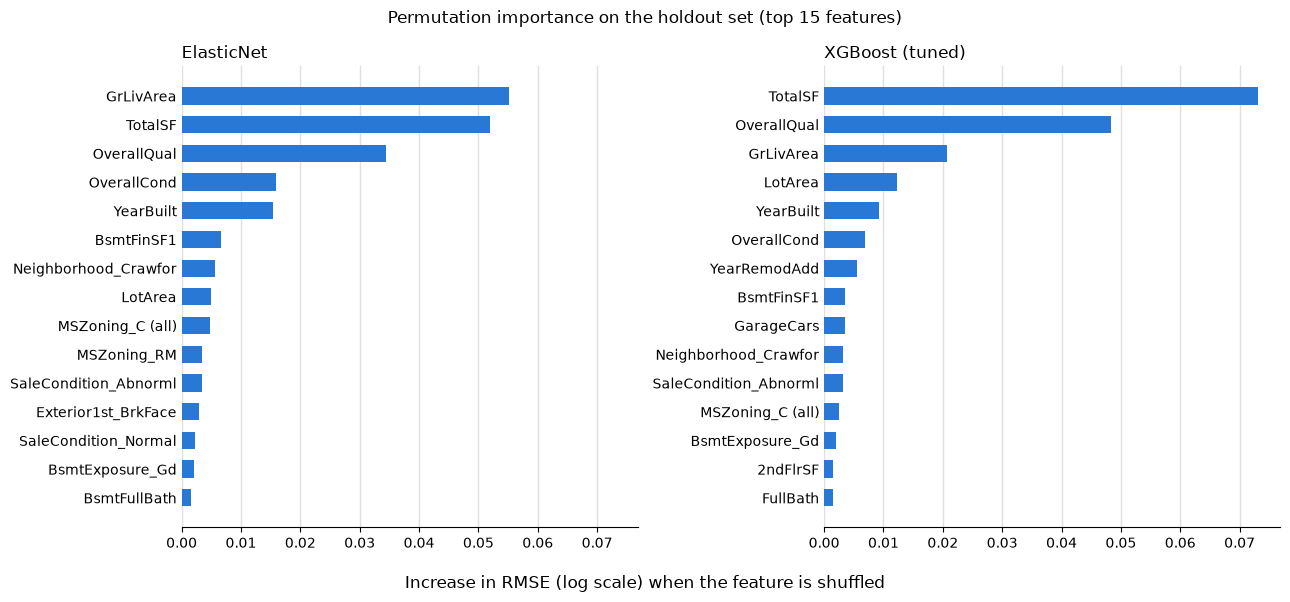

In [21]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# Best linear and best tree-based model by CV RMSE
models_to_explain = ['ElasticNet', 'XGBoost (tuned)']
top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True)
for ax, name in zip(axes, models_to_explain):
    result = permutation_importance(
        fitted_models[name], X_holdout, y_holdout,
        scoring='neg_root_mean_squared_error', n_repeats=10, random_state=42, n_jobs=-1,
    )
    importance = pd.Series(result.importances_mean, index=features).nlargest(top_n).sort_values()

    ax.barh(importance.index, importance.values, height=0.6, color='#2a78d6')
    ax.set_title(name, loc='left')
    ax.grid(axis='x', color='#e1e0d9', linewidth=1)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='y', length=0)

fig.suptitle(f'Permutation importance on the holdout set (top {top_n} features)')
fig.supxlabel('Increase in RMSE (log scale) when the feature is shuffled')
fig.tight_layout()
plt.show()